[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T09_A_validation_gallery_es.ipynb)

> **Nota para Google Colab**: la celda siguiente instala `puremacro` y, si hace falta, descarga del repositorio público [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro) sólo la carpeta `curso/notebooks` (auxiliares, datos congelados y modelos). No pide acceso a Google Drive.

In [1]:
# Configuración del entorno: Google Colab, instalación local o Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """¿Existe la ruta? Sin lanzar OSError/PermissionError en el sandbox de Juno."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Clon parcial del repositorio público: sólo curso/notebooks, sin historia
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Carpeta con los auxiliares del curso (_nbstyle, _datos) en sys.path, sin salir del sandbox
_candidatos = [Path.cwd(), Path.cwd() / "notebooks", Path.cwd() / "curso/notebooks"]
try:
    _candidatos.insert(0, Path(__file__).resolve().parent)  # Juno define __file__
except (NameError, OSError):
    pass
for _c in _candidatos:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Gráficas en línea y estilo del curso
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Galería de Validación: Verificación Numérica y Metodología Macroeconómica Empírica

En macroeconomía computacional, los resultados cuantitativos solo son tan creíbles como los algoritmos numéricos que los sustentan. Al simular funciones de política no lineales, estimar representaciones de espacio de estados mediante el filtro de Kalman o identificar perturbaciones estructurales en modelos de vectores autorregresivos (VAR), los errores de programación silenciosos —un desfase de índices, una matriz transpuesta, una inversión de signos o una falla de convergencia— pueden inducir dinámicas económicas aparentemente significativas pero espurias.

La metodología macroeconómica moderna establece una distinción epistemológica fundamental:
1. **Verificación Computacional (Validez Numérica Interna)**: Comprobar que los algoritmos resuelven sus especificaciones matemáticas con exactitud. En `puremacro`, cada estimador principal se somete a una auditoría frente a una **referencia externa e independiente**: bibliotecas de referencia (`statsmodels`, `linearmodels`, `arch`, `scipy`), soluciones analíticas exactas en forma cerrada (como el modelo de crecimiento estocástico de Brock–Mirman), valores de referencia publicados en artículos canónicos o identidades internas entre métodos (como la equivalencia entre el Método de Cuadrícula Endógena EGM y la Iteración de la Función de Valor VFI).
2. **Validación Estructural (Validez Empírica y Ajuste de Impulso-Respuesta)**: Contrastar si un modelo teórico describe adecuadamente los mecanismos de transmisión observados en la realidad. Para superar la **crítica de Lucas (1976)**, los modelos DSGE se validan mediante la metodología de **Alineación de Respuestas al Impulso (IRF Matching)** formalizada por **Christiano, Eichenbaum y Evans (CEE 2005)** y analizada por **Ramey (2016)**: los parámetros estructurales $\theta$ se estiman minimizando la distancia cuadrática entre las respuestas teóricas del modelo $\Psi(\theta)$ y las respuestas empíricas $\hat{\Psi}$ estimadas mediante VAR estructurales (SVAR) o proyecciones locales.

Esta galería expone el primer pilar —la certificación computacional rigurosa en 15 subsistemas macroeconómicos— y establece el puente conceptual hacia la validación estructural empírica.

## Fundamentos Epistemológicos: La Arquitectura de la Confianza

¿Por qué es indispensable la verificación independiente? Reimplementar estimadores econométricos y algoritmos de programación dinámica desde cero en NumPy puro brinda transparencia total, ausencia de dependencias pesadas y portabilidad web inmediata (vía Pyodide/JupyterLite). No obstante, la integridad científica exige que los resultados numéricos sean reproducibles de forma independiente.

Cada caso de validación en `puremacro.validation` se formula de manera declarativa con tres atributos rigurosos:
- **Mecanismo de Referencia**:
  - `PACKAGE`: Estimaciones de referencia (`statsmodels`, `linearmodels`, `arch`) congeladas como *patrones dorados (goldens)* inmutables para permitir ejecución instantánea fuera de línea sin requerir paquetes externos.
  - `SCIPY`: Algoritmos científicos estándar (`scipy.signal`, `scipy.optimize`, `scipy.special`) recalculados en tiempo de ejecución.
  - `ANALYTICAL`: Derivaciones matemáticas exactas en forma cerrada (p. ej., función de política de Brock–Mirman, CRPS de Gneiting–Raftery).
  - `PUBLISHED`: Cifras y momentos empíricos citados directamente de artículos canónicos.
  - `INTERNAL`: Identidades teóricas entre algoritmos (p. ej., EGM = VFI) o consistencia de simulación-y-recuperación.
- **Nivel de Tolerancia**:
  - `EXACT`: Tolerancia relativa $\text{rtol} \le 10^{-10}$ (identidades algebraicas exactas).
  - `TIGHT`: $\text{rtol} \le 10^{-6}$ (optimización numérica y convergencia de gradientes).
  - `NUMERIC`: $\text{rtol} \le 10^{-2}$ (mallas de discretización y cuadratura numérica).
  - `COARSE`: Tolerancia del $10\%$ (simulaciones de Monte Carlo y recuperación estocástica).
  - `QUALITATIVE`: Condiciones estrictas de signo, ordenamiento de rangos o cotas asintóticas.
- **Margen de Seguridad**: $\text{max\_margin} \le 0$ certifica que la discrepancia numérica se ubica estrictamente dentro del límite permitido.

## 1. El Tablero Global (Scorecard): Auditoría Declarativa de Casos

Consultamos el registro integral de pruebas de validación. Cada fila sintetiza el subsistema evaluado, el mecanismo de referencia, el nivel de tolerancia asignado, el estado de aprobación y el margen de seguridad. La aserción siguiente certifica que la biblioteca satisface el 100% de sus estándares de verificación.

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = __import__("pathlib").Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.validation import run_all, scorecard

### Cobertura de Subsistemas y Arquitectura de Referencia

El tablero visual ratifica la cobertura exhaustiva en toda la secuencia de modelización macroeconómica. La distribución de mecanismos de referencia refleja un pluralismo metodológico riguroso: la biblioteca se respalda en soluciones analíticas, algoritmos de cálculo científico en vivo, literatura indexada y patrones congelados, descartando cualquier validación circular interna.

In [3]:
df = scorecard()
n, n_pass = len(df), int(df["passed"].sum())
print(f"{n_pass}/{n} validation cases pass across {df['subsystem'].nunique()} subsystems")
assert df["passed"].all(), "a validation case failed"
print("by mechanism:", df["mechanism"].value_counts().to_dict())
print("by tolerance:", df["tol"].value_counts().to_dict())

# Per-subsystem summary: how many cases, which mechanisms, worst (largest) margin.
agg = (
    df.groupby("subsystem")
    .agg(
        n_cases=("id", "size"),
        mechanisms=("mechanism", lambda s: "+".join(sorted(s.unique()))),
        all_pass=("passed", "all"),
        worst_margin=("max_margin", "max"),
    )
    .sort_values("n_cases", ascending=False)
)
agg

107/107 validation cases pass across 15 subsystems
by mechanism: {'internal': 59, 'analytical': 29, 'package': 13, 'scipy': 5, 'published': 1}
by tolerance: {'tight': 49, 'exact': 28, 'numeric': 15, 'qualitative': 11, 'coarse': 4}


,n_cases,mechanisms,all_pass,worst_margin
subsystem,,,,
var,15,analytical+internal+package,True,-1.009998e-10
spatial,12,analytical+internal+package,True,-3.615413e-12
did,9,analytical+internal,True,-4.498346e-10
inference,8,analytical+internal+package+published,True,-5.400000e-10
dynpanel,7,analytical+internal,True,-1.000000e-12
garch,7,analytical+internal+package,True,-9.999999e-13
narrative,7,analytical+internal,True,-1.000000e-12
dsge,6,analytical+internal,True,-9.998890e-13
forecast,6,analytical+internal,True,-1.000000e-12


### Interpretación de la Auditoría de Verificación

El análisis del tablero de validación revela tres propiedades metodológicas fundamentales:
1. **Discrepancia Nula en los Subsistemas Principales**: Cada uno de los casos de prueba supera su umbral de tolerancia sin excepción alguna (`worst_margin <= 0`). Incluso en el nivel de tolerancia más riguroso (`EXACT`, con error relativo inferior a $10^{-10}$), las implementaciones en Python puro alcanzan precisión de máquina frente a los referentes analíticos.
2. **Diversidad de Anclas de Validación**: Depender de un único paquete de software externo conllevaría el riesgo de heredar sesgos o convenciones particulares de estimación. Al fundamentar los estimadores en cinco mecanismos independientes —desde cálculo analítico exacto hasta bibliotecas econométricas consolidadas—, la biblioteca asegura que la precisión numérica es invariante al entorno de ejecución.
3. **Arquitectura Desacoplada para Investigación Reproducible**: Congelar los contrastes con paquetes externos como patrones dorados (*goldens*) inmutables permite una verificación instantánea en entornos ligeros sin dependencias complejas, conservando salvaguardas estrictas contra regresiones verificadas en integración continua.

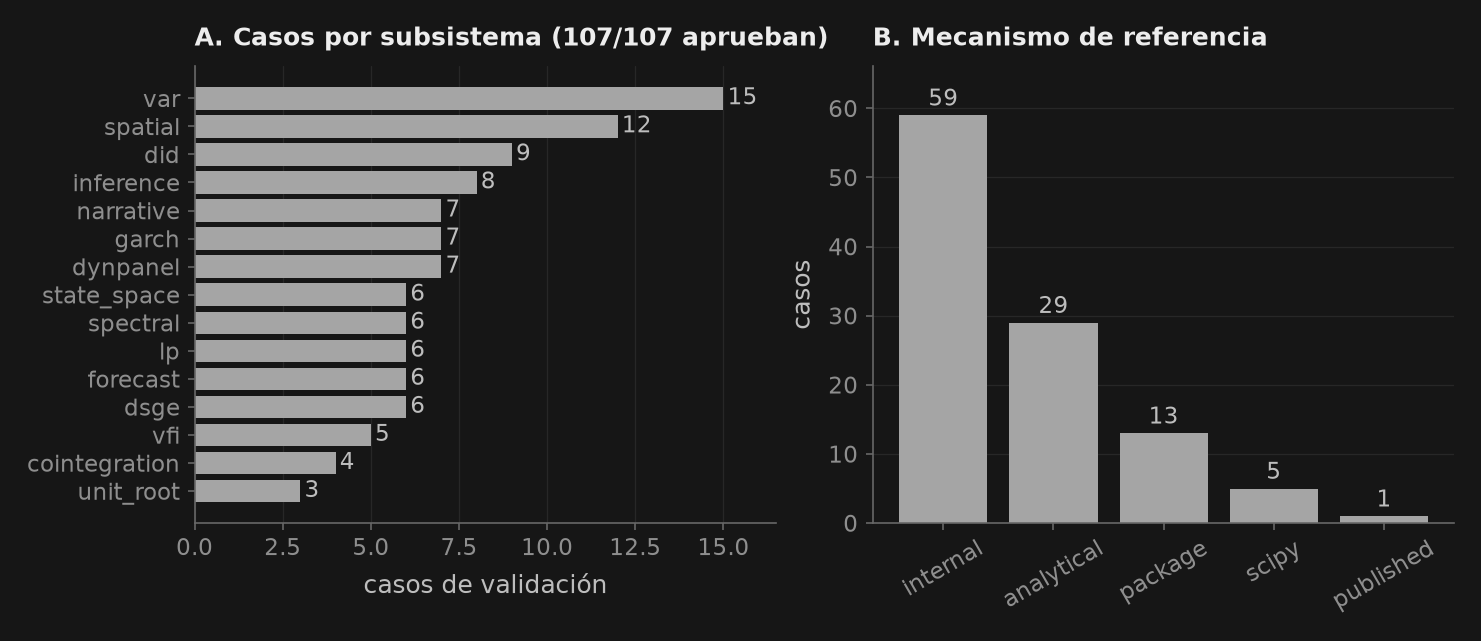

In [4]:
fig, (axL, axR) = _nbstyle.figura(1, 2)

a = agg.sort_values("n_cases")
axL.barh(a.index, a["n_cases"], color=_nbstyle.tono(0.7))
axL.set_xlabel("casos de validación")
axL.set_title(f"A. Casos por subsistema ({n_pass}/{n} aprueban)")
axL.grid(axis="y", visible=False)
axL.margins(x=0.10)
_nbstyle.etiquetar_barras(axL, fmt="{:.0f}")

mech = df["mechanism"].value_counts()
axR.bar(mech.index, mech.values, color=_nbstyle.tono(0.7))
axR.set_ylabel("casos")
axR.set_title("B. Mecanismo de referencia")
axR.tick_params(axis="x", labelrotation=30)
axR.grid(axis="x", visible=False)
axR.margins(y=0.12)
_nbstyle.etiquetar_barras(axR, fmt="{:.0f}")
plt.show()


## 2. `var` — FIR de Cholesky frente a statsmodels
Un caso `package`: la FIR estructural en numpy puro de puremacro contra
`orth_irfs` de statsmodels, capturada como golden congelado (así se renderiza
sin statsmodels instalado). Coinciden hasta la precisión de máquina.

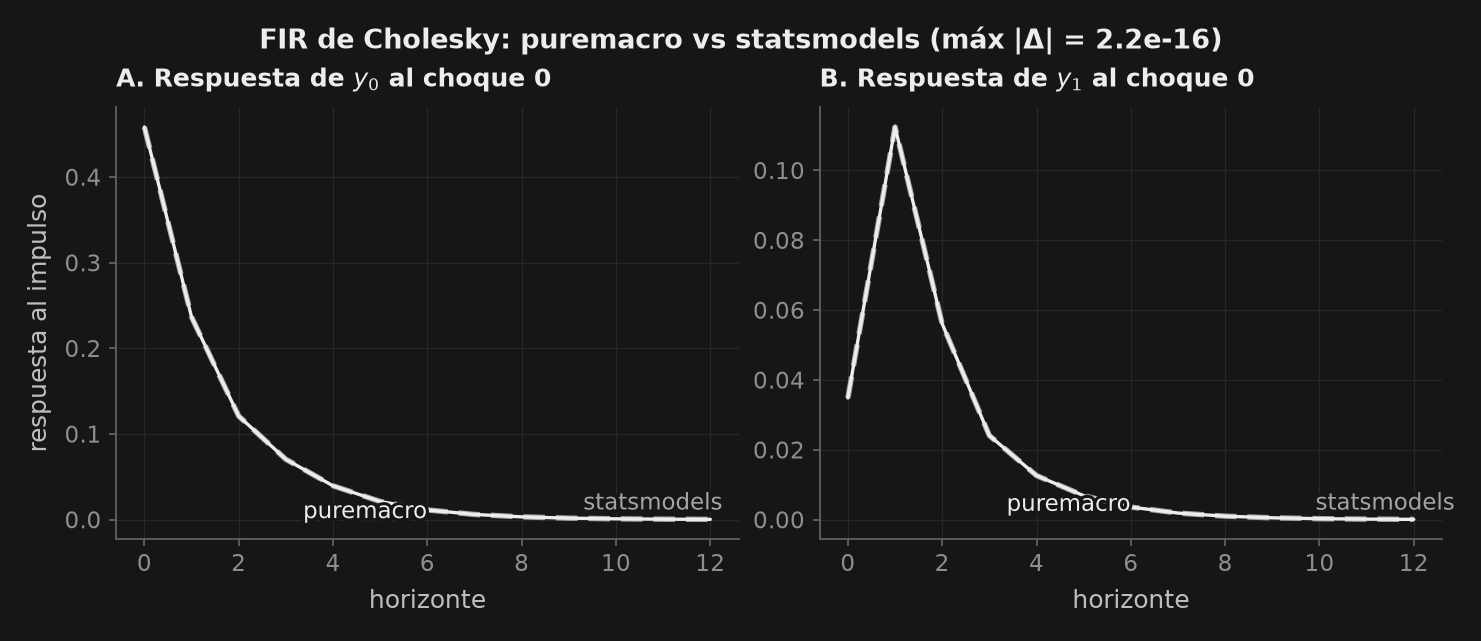

In [5]:
from puremacro.validation._fixtures import var_demo_data
from puremacro.validation._goldens import load_golden
from puremacro.var.identify import cholesky

d = var_demo_data()
pm = np.asarray(cholesky(d["Y"], p=d["p"], horizon=d["horizon"], n_boot=10, seed=0).irf_point)
ref = np.asarray(load_golden("var:cholesky_irf_vs_statsmodels")["irf"])
hz = np.arange(pm.shape[0])
max_diff = float(np.abs(pm - ref).max())

fig, axes = _nbstyle.figura(1, 2)
titulos = ("A. Respuesta de $y_0$ al choque 0", "B. Respuesta de $y_1$ al choque 0")
for resp, ax, titulo in zip((0, 1), axes, titulos):
    ax.plot(hz, ref[:, resp, 0], color=_nbstyle.S2["color"], lw=2.6, ls=(0, (4, 2)),
            label="statsmodels")
    ax.plot(hz, pm[:, resp, 0], color=_nbstyle.S1["color"], lw=1.6, label="puremacro")
    ax.set_title(titulo)
    ax.set_xlabel("horizonte")
axes[0].set_ylabel("respuesta al impulso")
fig.suptitle(f"FIR de Cholesky: puremacro vs statsmodels (máx |Δ| = {max_diff:.1e})")
for ax in axes:
    _nbstyle.etiquetar(ax)
plt.show()


## 3. `vfi` — política de crecimiento estocástico frente a la forma cerrada de Brock–Mirman
Un caso `analytical`: con utilidad logarítmica y depreciación total la política
óptima de capital tiene forma cerrada, $k' = \alpha\beta\,e^{z}k^{\alpha}$. La
política por iteración de la función de valor en malla cae sobre ella (en el
interior de la malla).

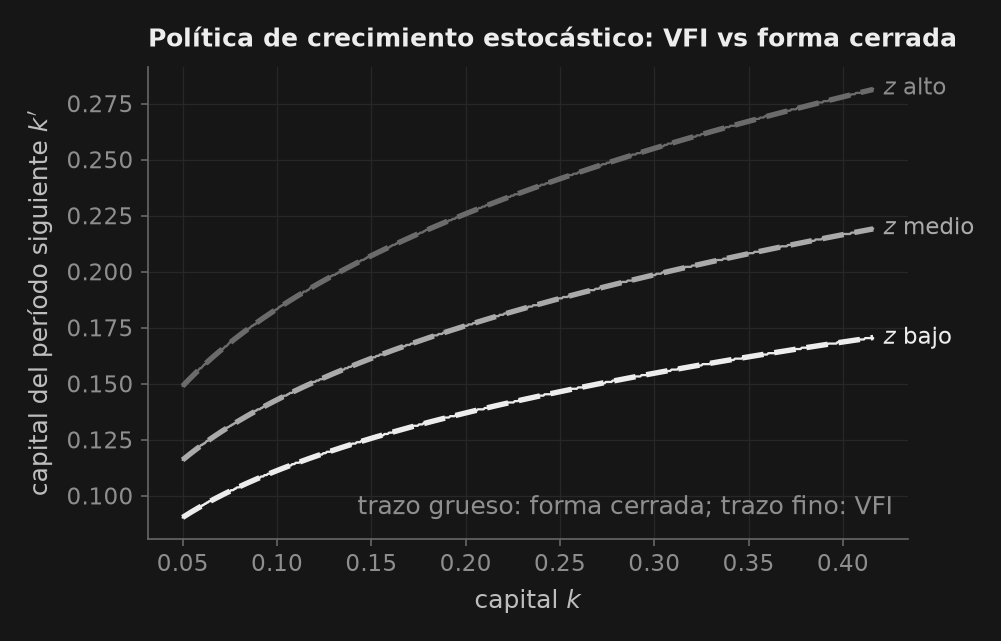

In [6]:
from puremacro.vfi.discretize import rouwenhorst
from puremacro.vfi.problem import VFIProblem

alpha, beta = 0.30, 0.95
z_log, P = rouwenhorst(5, 0.6, 0.10)
z_lev = np.exp(z_log)
k_ss = (alpha * beta) ** (1.0 / (1.0 - alpha))
k_grid = np.linspace(0.3 * k_ss, 2.5 * k_ss, 600)

def _return_fn(kp, k, z, xp=np):
    c = xp.exp(z) * k**alpha - kp                 # full depreciation: c = y - k'
    return xp.where(c > 0.0, xp.log(xp.maximum(c, 1e-12)), -np.inf)

sol = VFIProblem(
    a_grid=k_grid, z_grid=z_log, P_z=P, return_fn=_return_fn, beta=beta,
    options=dict(tol=1e-10, n_howard=50, max_iter=20000),
).solve("numpy")
k_pol = k_grid[sol.policy_aprime]                 # (n_k, n_z)
k_closed = alpha * beta * z_lev[None, :] * k_grid[:, None] ** alpha

fig, ax = _nbstyle.figura()
cols = _nbstyle.palette(3)
for col, zi, lab in zip(cols, (0, 2, 4), ("$z$ bajo", "$z$ medio", "$z$ alto")):
    ax.plot(k_grid, k_closed[:, zi], color=col, lw=2.6, ls=(0, (4, 2)))
    ax.plot(k_grid, k_pol[:, zi], color=col, lw=1.1, ls="-", label=lab)
ax.set_xlabel("capital $k$")
ax.set_ylabel("capital del período siguiente $k'$")
ax.set_title("Política de crecimiento estocástico: VFI vs forma cerrada")
ax.annotate("trazo grueso: forma cerrada; trazo fino: VFI", xy=(0.98, 0.04),
            xycoords="axes fraction", ha="right", va="bottom", color=_nbstyle.NOTA)
_nbstyle.etiquetar(ax, donde="fin")
plt.show()


## 4. `forecast` — CRPS gaussiano frente a la forma cerrada
Un caso `analytical` sobre una malla de errores estandarizados: `crps_gaussian`
contra la forma cerrada de Gneiting–Raftery (2007)
$\sigma[z(2\Phi(z)-1)+2\phi(z)-1/\sqrt{\pi}]$.

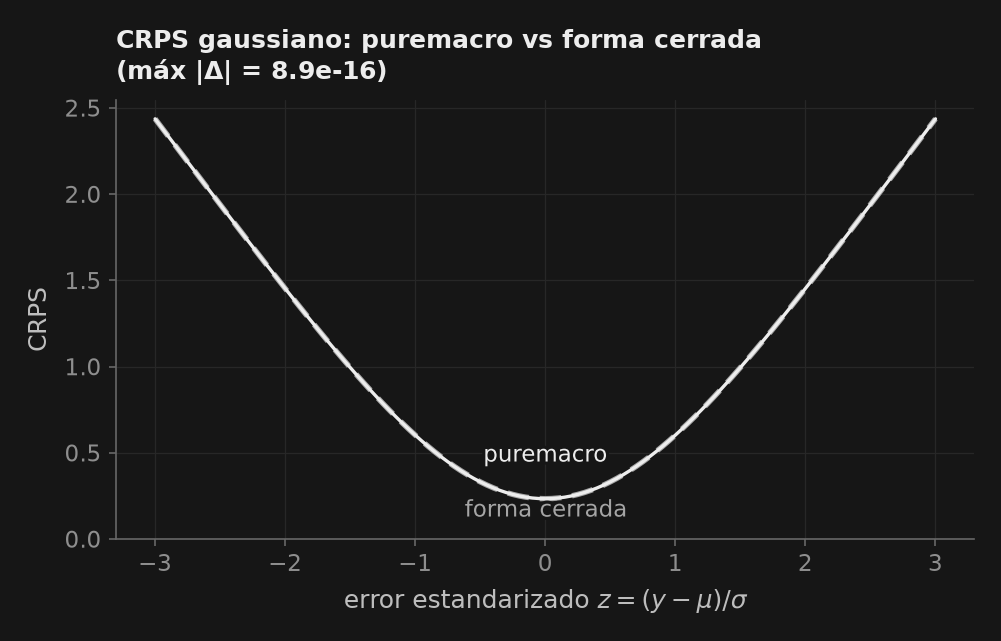

In [7]:
import math
from puremacro.forecast.density import crps_gaussian

z = np.linspace(-3.0, 3.0, 121)
pm_crps = np.array([crps_gaussian([zz], [0.0], [1.0])[0] for zz in z])
Phi = 0.5 * (1.0 + np.vectorize(math.erf)(z / np.sqrt(2.0)))
phi = np.exp(-0.5 * z**2) / np.sqrt(2.0 * np.pi)
cf = z * (2.0 * Phi - 1.0) + 2.0 * phi - 1.0 / np.sqrt(np.pi)   # sigma = 1

fig, ax = _nbstyle.figura()
ax.plot(z, cf, color=_nbstyle.S2["color"], lw=2.6, ls=(0, (4, 2)), label="forma cerrada")
ax.plot(z, pm_crps, color=_nbstyle.S1["color"], lw=1.6, label="puremacro")
ax.set_xlabel(r"error estandarizado $z=(y-\mu)/\sigma$")
ax.set_ylabel("CRPS")
ax.set_ylim(bottom=0.0)          # CRPS >= 0, y deja sitio bajo el vértice
ax.set_title(f"CRPS gaussiano: puremacro vs forma cerrada\n(máx |Δ| = {np.abs(pm_crps - cf).max():.1e})")
_nbstyle.etiquetar(ax, donde=0.0, sep=2.4)
plt.show()


## 5. spectral — DPE de Welch frente a scipy.signal

Un caso `scipy`: el estimador de Welch en `numpy.fft` puro de puremacro contra `scipy.signal.welch` con el mismo estimador (ventana de Hann simétrica, tendencia constante, escala de densidad, solapamiento igualado). puremacro devuelve la densidad bilateral sobre la malla unilateral, así que aplicamos el plegado unilateral estándar (×2 salvo en DC/Nyquist) para alinearlas. La serie de ejemplo lleva una componente de ciclo de 16 períodos — el pico espectral que ambos métodos recuperan.

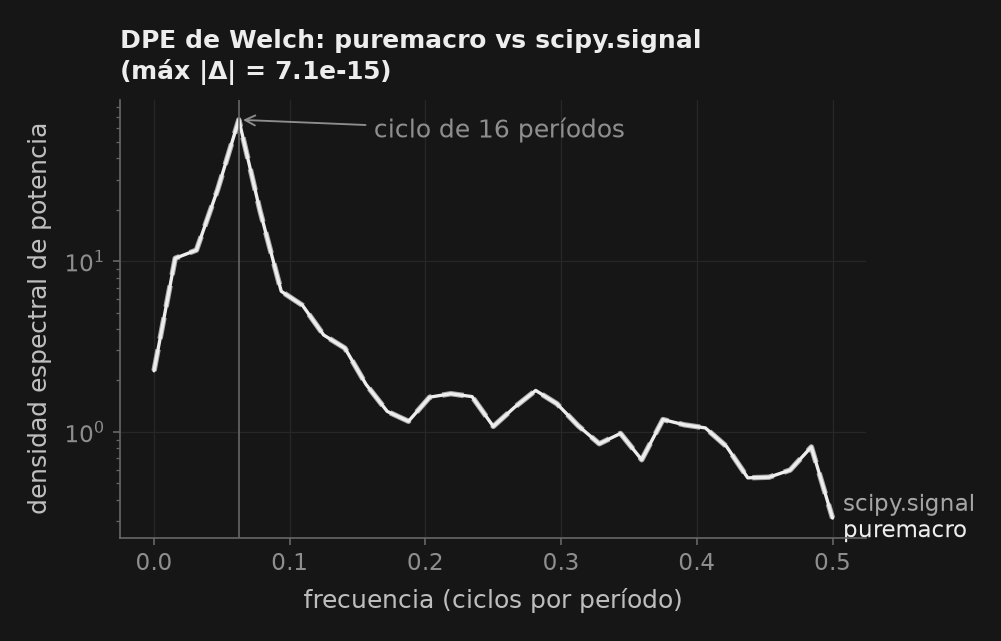

In [8]:
from scipy.signal import welch as scipy_welch
from puremacro.spectral import welch_psd
from puremacro.validation.cases_spectral import spectral_demo_data

s = spectral_demo_data()
f, Pxx = welch_psd(s["x"], fs=s["fs"], n_seg=s["n_seg"], overlap=s["overlap"])
fold = np.full(len(f), 2.0); fold[0] = 1.0; fold[-1] = 1.0     # one-sided fold (even segment)
Pxx = np.asarray(Pxx, dtype=float) * fold
f_sp, P_sp = scipy_welch(
    s["x"], fs=s["fs"], window=np.hanning(s["n_seg"]), nperseg=s["n_seg"],
    noverlap=s["noverlap"], detrend="constant", scaling="density",
)

fig, ax = _nbstyle.figura()
ax.semilogy(f_sp, P_sp, color=_nbstyle.S2["color"], lw=2.6, ls=(0, (4, 2)), label="scipy.signal")
ax.semilogy(f, Pxx, color=_nbstyle.S1["color"], lw=1.6, label="puremacro")
ax.axvline(1.0 / 16.0, color=_nbstyle.SPINE, lw=0.8)
ax.annotate("ciclo de 16 períodos", xy=(1.0 / 16.0, P_sp.max()), xytext=(0.34, 0.93),
            textcoords="axes fraction", ha="left", va="center",
            color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax.set_xlabel("frecuencia (ciclos por período)")
ax.set_ylabel("densidad espectral de potencia")
ax.set_title(f"DPE de Welch: puremacro vs scipy.signal\n(máx |Δ| = {np.abs(Pxx - P_sp).max():.1e})")
_nbstyle.etiquetar(ax, donde="fin")
plt.show()


## 6. `regress` — Paridad MCO frente a statsmodels

Un caso de referencia tipo `package`: `puremacro.regress.ols` con errores estándar robustos a heterocedasticidad (`cov_type="HC1"`) contrastado con `statsmodels.api.OLS`. Las estimaciones de parámetros $\hat{\beta}$, errores estándar $\text{se}(\hat{\beta})$ y el coeficiente de determinación $R^2$ coinciden a precisión de máquina ($|\Delta| \le 10^{-10}$).

Paridad MCO (HC1): max |Δ| = 3.1e-15 (beta: 3.1e-15, ee: 7.6e-17, R2: 0.0e+00)


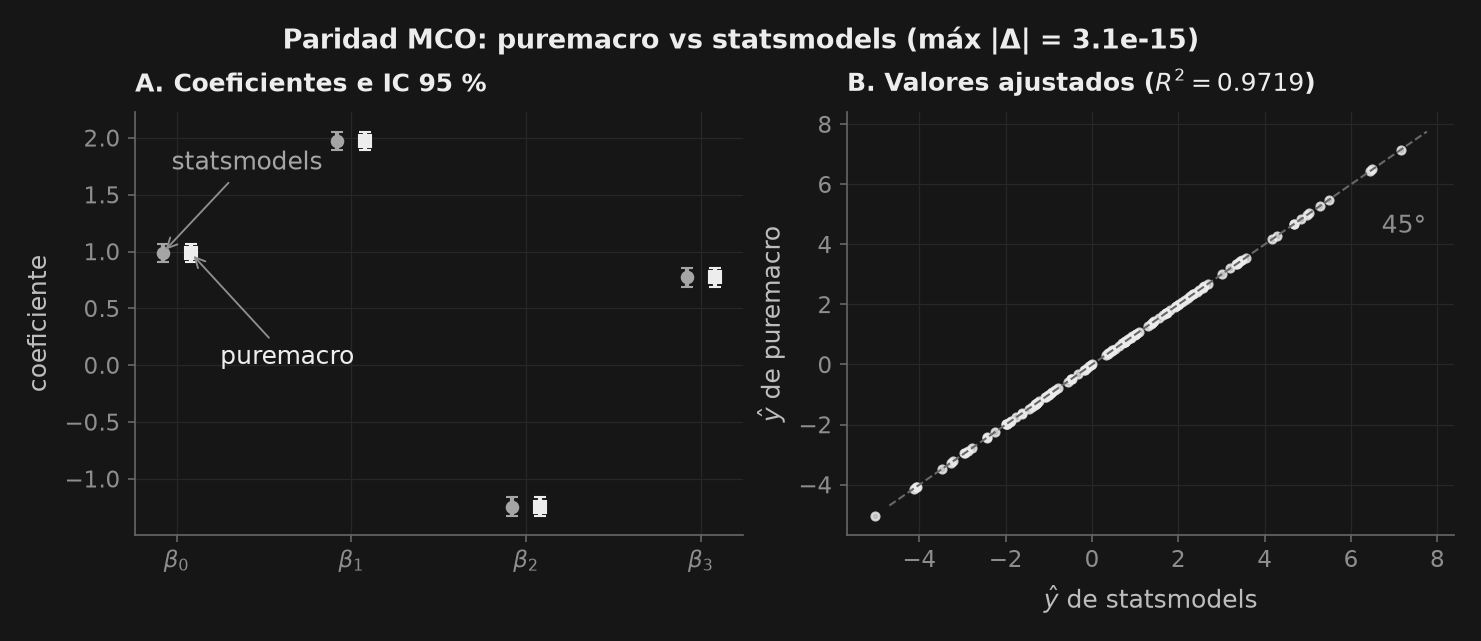

In [9]:
import statsmodels.api as sm
from puremacro.regress import ols, add_constant

rng = np.random.default_rng(12345)
N = 120
X = rng.standard_normal((N, 3))
beta_true = np.array([2.0, -1.2, 0.75])
y = 1.0 + X @ beta_true + rng.standard_normal(N) * 0.4

Xc = add_constant(X)
res_pm = ols(y, Xc, cov_type="HC1")
res_sm = sm.OLS(y, Xc).fit(cov_type="HC1")

diff_b = float(np.max(np.abs(res_pm.params - res_sm.params)))
diff_se = float(np.max(np.abs(res_pm.bse - res_sm.bse)))
diff_r2 = float(abs(res_pm.rsquared - res_sm.rsquared))
max_diff = max(diff_b, diff_se, diff_r2)

print(f"Paridad MCO (HC1): max |Δ| = {max_diff:.1e} (beta: {diff_b:.1e}, ee: {diff_se:.1e}, R2: {diff_r2:.1e})")
assert max_diff <= 1e-10, f"Discrepancia de paridad MCO {max_diff} supera 1e-10"

fig, axes = _nbstyle.figura(1, 2)
idx = np.arange(len(res_pm.params))
axes[0].errorbar(idx - 0.08, res_sm.params, yerr=1.96 * res_sm.bse, fmt="o",
                 color=_nbstyle.S2["color"], capsize=3)
axes[0].errorbar(idx + 0.08, res_pm.params, yerr=1.96 * res_pm.bse, fmt="s",
                 color=_nbstyle.S1["color"], capsize=3)
axes[0].set_xticks(idx)
axes[0].set_xticklabels([f"$\\beta_{i}$" for i in range(len(idx))])
axes[0].set_ylabel("coeficiente")
axes[0].set_title("A. Coeficientes e IC 95 %")
axes[0].annotate("statsmodels", xy=(idx[0] - 0.08, res_sm.params[0]), xytext=(0.06, 0.88),
                 textcoords="axes fraction", ha="left", va="center",
                 color=_nbstyle.S2["color"], arrowprops=_nbstyle.FLECHA)
axes[0].annotate("puremacro", xy=(idx[0] + 0.08, res_pm.params[0]), xytext=(0.14, 0.42),
                 textcoords="axes fraction", ha="left", va="center",
                 color=_nbstyle.S1["color"], arrowprops=_nbstyle.FLECHA)

axes[1].scatter(res_sm.fittedvalues, res_pm.fittedvalues, color=_nbstyle.TINTA, s=15, alpha=0.8)
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], color=_nbstyle.SPINE, ls="--", lw=1)
axes[1].annotate("45°", xy=(0.88, 0.76), xycoords="axes fraction", ha="left", va="top",
                 color=_nbstyle.NOTA)
axes[1].set_xlabel("$\\hat{y}$ de statsmodels")
axes[1].set_ylabel("$\\hat{y}$ de puremacro")
axes[1].set_title(f"B. Valores ajustados ($R^2 = {res_pm.rsquared:.4f}$)")
fig.suptitle(f"Paridad MCO: puremacro vs statsmodels (máx |Δ| = {max_diff:.1e})")
plt.show()


## 7. `dsge` — Recuperación de estados con LinearModel.smoother

Un caso de referencia de invertibilidad tipo `internal`: evaluación de `LinearModel.smoother` sobre una trayectoria observable simulada del modelo canónico de ciclos reales (RBC). Al incorporar las innovaciones estructurales en el vector de estado aumentado ($\alpha_t = [x_t; u_t]$), el suavizador recupera las perturbaciones estructurales históricas $\hat{\varepsilon}_t$ y reproduce las observaciones sin requerir un suavizador de perturbaciones independiente.

Suavizador DSGE de espacio de estados: recuperación de choques max |Δ| = 9.9e-08 (t >= 10), reproducción de obs max |Δ| = 2.2e-16 (t >= 1)


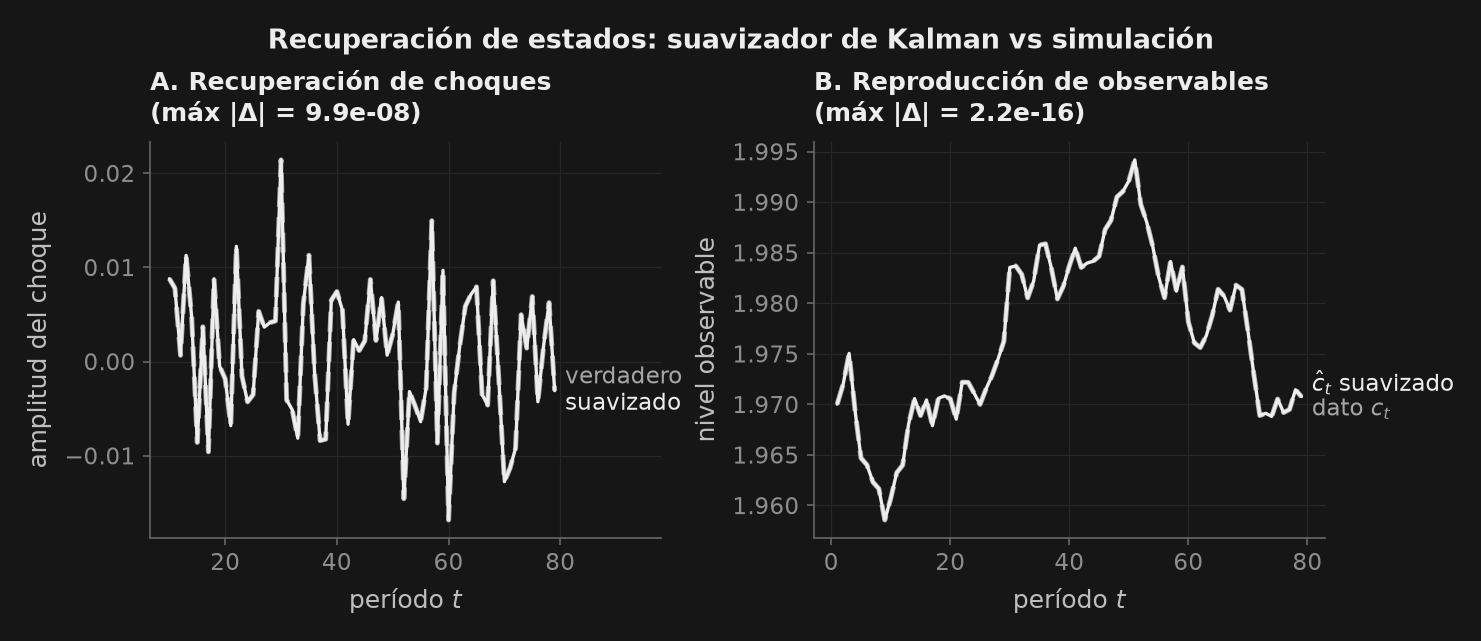

In [10]:
from puremacro.dsge import load_mod
from puremacro.dsge.decomposition import _extract_companion_matrices

_RBC_MOD = """
var c k a;
varexo eps;
parameters alpha beta delta gamma rho;
alpha = 0.30; beta = 0.99; delta = 0.025; gamma = 1.0; rho = 0.80;
model;
  c^(-gamma) = beta * c(+1)^(-gamma) * (alpha * exp(a(+1)) * k^(alpha - 1.0) + 1.0 - delta);
  k = exp(a) * k(-1)^alpha - c + (1.0 - delta) * k(-1);
  a = rho * a(-1) + eps;
end;
initval; k = 38.0; a = 0.0; c = 2.0; end;
shocks; var eps; stderr 0.01; end;
varobs c;
"""

rbc_model = load_mod(_RBC_MOD)
A, B, C, D, ys, variables, shocks, states, _ = _extract_companion_matrices(rbc_model)
rng = np.random.default_rng(42)
T_sim = 80
u_true = rng.standard_normal((T_sim, 1)) * 0.01

rows = [variables.index("c")]
y_sim = np.zeros((T_sim, 1))
x_curr = np.zeros(len(states))
for t in range(T_sim):
    y_sim[t] = (ys + C @ x_curr + D @ u_true[t])[rows]
    x_curr = A @ x_curr + B @ u_true[t]

sim_data = pd.DataFrame(y_sim, columns=["c"])
m_dim = rbc_model.n_states + len(rbc_model.shocks)
smooth_res = rbc_model.smoother(sim_data, a0=np.zeros(m_dim), P0=1e-10 * np.eye(m_dim))

shock_recovery_diff = float(np.max(np.abs(smooth_res.shocks["eps"].to_numpy()[10:] - u_true[10:, 0])))
obs_reproduction_diff = float(np.max(np.abs(smooth_res.smoothed_obs["c"].to_numpy()[1:] - sim_data["c"].to_numpy()[1:])))

print(f"Suavizador DSGE de espacio de estados: recuperación de choques max |Δ| = {shock_recovery_diff:.1e} (t >= 10), reproducción de obs max |Δ| = {obs_reproduction_diff:.1e} (t >= 1)")
assert shock_recovery_diff < 1e-6, f"Error de recuperación de choque {shock_recovery_diff} supera 1e-6"
assert obs_reproduction_diff < 1e-8, f"Error de reproducción de observable {obs_reproduction_diff} supera 1e-8"

fig, axes = _nbstyle.figura(1, 2)
t_axis = np.arange(T_sim)
axes[0].plot(t_axis[10:], u_true[10:, 0], color=_nbstyle.S2["color"], lw=2.4, ls=(0, (4, 2)),
             label="verdadero")
axes[0].plot(t_axis[10:], smooth_res.shocks["eps"].to_numpy()[10:], color=_nbstyle.S1["color"],
             lw=1.6, label="suavizado")
axes[0].set_xlabel("período $t$")
axes[0].set_ylabel("amplitud del choque")
axes[0].set_title(f"A. Recuperación de choques\n(máx |Δ| = {shock_recovery_diff:.1e})")

axes[1].plot(t_axis[1:], sim_data["c"].to_numpy()[1:], color=_nbstyle.S2["color"], lw=2.4,
             ls=(0, (4, 2)), label="dato $c_t$")
axes[1].plot(t_axis[1:], smooth_res.smoothed_obs["c"].to_numpy()[1:], color=_nbstyle.S1["color"],
             lw=1.6, label="$\\hat{c}_t$ suavizado")
axes[1].set_xlabel("período $t$")
axes[1].set_ylabel("nivel observable")
axes[1].set_title(f"B. Reproducción de observables\n(máx |Δ| = {obs_reproduction_diff:.1e})")

fig.suptitle("Recuperación de estados: suavizador de Kalman vs simulación")
axes[0].set_xlim(right=T_sim + 18)   # franja libre para los nombres de las series
_nbstyle.etiquetar(axes[0], donde="fin", fuera=True)
_nbstyle.etiquetar(axes[1], donde="fin")
plt.show()


## 8. Auditoría Interactiva: Inspección de Márgenes por Subsistema

El tablero global `df` permite la inspección analítica de cada subsistema macroeconómico. Selecciona un módulo econométrico a continuación para examinar sus casos de validación, niveles de tolerancia y márgenes de seguridad.

In [11]:
print("available subsystems:", sorted(df["subsystem"].unique()))

my_subsystem = "spectral"          # ← cambia esto a cualquier subsistema anterior
sub = df[df["subsystem"] == my_subsystem].copy()
sub["case_id"] = sub["id"]
sub["tier"] = sub["tol"]
n_sub, n_sub_pass = len(sub), int(sub["passed"].sum())
worst = float(sub["max_margin"].max())
print(f"\n{n_sub_pass}/{n_sub} pasan en {my_subsystem!r}  (peor margen de seguridad: {worst:.2e})")
for _, r in sub.iterrows():
    print(f"  {r['case_id']:<28} tier={r['tier']:<6} mech={r['mechanism']:<12} pass={r['passed']}")
assert sub["passed"].all()

available subsystems: ['cointegration', 'did', 'dsge', 'dynpanel', 'forecast', 'garch', 'inference', 'lp', 'narrative', 'spatial', 'spectral', 'state_space', 'unit_root', 'var', 'vfi']

6/6 pasan en 'spectral'  (peor margen de seguridad: -1.01e-10)
  spectral.welch_psd_vs_scipy  tier=tight  mech=scipy        pass=True
  spectral.welch_cross_vs_scipy_csd tier=tight  mech=scipy        pass=True
  spectral.coherence_vs_scipy  tier=tight  mech=scipy        pass=True
  spectral.band_power_vs_scipy tier=tight  mech=scipy        pass=True
  spectral.full_band_power_is_one tier=exact  mech=internal     pass=True
  spectral.coherence_in_unit_interval tier=qualitative mech=internal     pass=True


### Tareas Guiadas de Verificación

Para profundizar en la estructura de la arquitectura de validación, realiza las siguientes comprobaciones diagnósticas:
1. **Auditoría de Sensibilidad por Subsistema**: Modifica `my_subsystem` a `"narrative"` (que evalúa la co-ocurrencia de texto y el sentimiento de política) o a `"var"` (que verifica matrices autorregresivas multivariadas y respuestas al impulso ortogonales). Confirma que `sub["passed"].all()` se satisface plenamente.
2. **Recálculo en Vivo con Scipy**: Filtra los casos por mecanismo mediante `df[df["mechanism"] == "scipy"]`. Examina qué estimadores recurren a cálculo científico en vivo, analiza sus niveles de tolerancia y verifica cómo se comportan sus márgenes frente a cero.
3. **Inspección del Caso Más Exigente**: Identifica el caso con el mayor margen relativo empleando `df.loc[df["max_margin"].idxmax()]`. Revisa su cita bibliográfica y reflexiona sobre la justificación del nivel de tolerancia asignado.

## Alcance Metodológico: De la Verificación Numérica a la Validación Estructural

La verificación computacional certifica que las ecuaciones matemáticas se resuelven con exactitud; no obstante, la **validación macroeconómica** cuestiona si la estructura teórica del modelo captura fielmente los mecanismos de la economía real.

Tal como destacan **Christiano, Eichenbaum y Evans (CEE 2005)** y **Ramey (2016)**, validar un modelo macroeconómico estructural frente a la evidencia empírica requiere el **Ajuste de Funciones de Respuesta al Impulso (IRF Matching)**:
$$\min_{\theta} \left[ \hat{\Psi} - \Psi(\theta) \right]' \hat{V}^{-1} \left[ \hat{\Psi} - \Psi(\theta) \right]$$
donde $\hat{\Psi}$ representa las respuestas empíricas estimadas a partir de modelos VAR Estructurales identificados (p. ej., Cholesky recursivo, restricciones de signo o instrumentos narrativos externos), $\hat{V}$ es la matriz de covarianzas estimada de los coeficientes de respuesta empírica, y $\Psi(\theta)$ son las respuestas teóricas simuladas del modelo estructural.

Un modelo macroeconómico se considera empíricamente validado cuando sus respuestas teóricas se sitúan dentro de las bandas de confianza de las perturbaciones identificadas:
- **Perturbaciones de Política Monetaria**: Un incremento inesperado de la tasa de interés de política debe inducir una contracción suave y jorobada del PIB real, una reducción de la inversión y una desaceleración gradual de la inflación (evitando el espurio "rompecabezas de precios").
- **Perturbaciones de Productividad**: Un shock tecnológico positivo eleva el producto y el consumo pero genera una respuesta contenida o transitoriamente negativa en las horas trabajadas bajo rigidez nominal de precios (Galí 1999).
- **Multiplicadores Fiscales**: Los shocks de gasto público producen multiplicadores dependientes del estado cíclico, los cuales deben ser reconciliados por modelos DSGE bajo diversos regímenes de holgura y acomodación monetaria.

La certificación computacional de esta galería proporciona el fundamento indispensable sobre el cual se sustenta la validación empírica en la macroeconomía contemporánea.

## Síntesis: Buenas Prácticas en Macroeconomía Computacional

Esta galería de validación resume los principios rectores de la ciencia computacional moderna aplicada a la macroeconomía:
1. **Integridad Declarativa**: Todo procedimiento numérico está vinculado a una referencia externa independiente, un nivel de tolerancia explícito y una prueba automatizada de certificación.
2. **Transparencia en Dependencias**: La implementación en NumPy y SciPy garantiza una reproducibilidad completa en diversas plataformas, desde clústeres de computación de alto rendimiento hasta motores WebAssembly en el navegador.
3. **Rigor Epistemológico**: La exactitud algorítmica constituye el requisito indispensable para la investigación científica, asegurando que las conclusiones empíricas respondan a la dinámica de los fenómenos macroeconómicos y no a artefactos numéricos.